# 05 — Forecasting (final deliverable)

Generates the 12-week-ahead forecasts using the **best model per tier** from
step 4:

* **Tier A, B** → global LightGBM, **volume-bias-corrected** (best per-week
  accuracy; a per-tier factor restores realistic total volume).
* **Tier C** → moving-average baseline (best on both metrics for the sparse tail).

Two deliverables are written to `outputs/forecasts/`:
* `product_12_week_forecast.csv`
* `product_country_12_week_forecast.csv` (top-down split of the product forecast
  by each product's recent country share, so country sums = product totals).

Unlike step 4, models are retrained on **all** history and we forecast the 12
weeks *after* the last observed week. Logic is in `src/forecast.py`.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, features as fe, forecast as fc
KEY, WK, QTY = config.COL_PRODUCT9, config.COL_WEEK, config.COL_SALES_QTY
pd.set_option("display.width", 160); config.ensure_dirs()

## Load inputs

In [2]:
weekly = fe.load_weekly_product(); tiers = fe.load_tiers()
feat = pd.read_parquet(config.PROCESSED_DIR / "feature_table.parquet")
clean = fe.load_cleaned()
fweeks = fc.future_weeks(weekly)
print("forecast weeks:", fweeks[0].date(), "..", fweeks[-1].date())

forecast weeks: 2025-09-22 .. 2025-12-08


## Build the product-level forecast

Estimates the bias correction on a 12-week backtest, retrains LightGBM on all data, forecasts recursively, and routes Tier C to moving-average. Takes a few minutes.

In [3]:
product_fc, factors = fc.forecast_products(weekly, tiers, feat, clean)
print("bias-correction factors:", {k: round(v, 2) for k, v in factors.items()})
print("rows:", f"{len(product_fc):,}", "| products:", product_fc[KEY].nunique())
product_fc.head()

bias-correction factors: {'A': 3.37, 'B': 4.96, 'C': 1.0}
rows: 164,688 | products: 13724


,Product9,week_start,forecast_qty,tier,model_used
0,10015-015,2025-09-22,2.00,B,LightGBM(bias-corrected)
1,10016-032,2025-09-22,20.02,B,LightGBM(bias-corrected)
2,10063-041,2025-09-22,14.95,B,LightGBM(bias-corrected)
3,10073-080,2025-09-22,22.82,B,LightGBM(bias-corrected)
4,10080-099,2025-09-22,36.06,B,LightGBM(bias-corrected)


In [4]:
# total forecast volume by tier and model used
print(product_fc.groupby(["tier", "model_used"])["forecast_qty"]
      .agg(["sum", "mean"]).round(1))

                                    sum   mean
tier model_used                               
A    LightGBM(bias-corrected)  653528.4  127.2
B    LightGBM(bias-corrected)  556258.9   18.4
C    MovingAvg8                276007.4    2.1


## Disaggregate to product × country

In [5]:
country_fc = fc.disaggregate_to_country(product_fc, clean)
s_p, s_c = product_fc["forecast_qty"].sum(), country_fc["forecast_qty"].sum()
print(f"product total={s_p:,.0f}  country total={s_c:,.0f}  "
      f"({'consistent' if abs(s_p-s_c)/max(s_p,1)<0.02 else 'CHECK'})")
country_fc.head()

product total=1,485,795  country total=1,485,794  (consistent)


,Product9,Country,week_start,forecast_qty,tier,model_used
0,10015-015,INDONESIA,2025-09-22,2.00,B,LightGBM(bias-corrected)
1,10016-032,NETHERLANDS,2025-09-22,20.02,B,LightGBM(bias-corrected)
2,10063-041,UNKNOWN,2025-09-22,14.95,B,LightGBM(bias-corrected)
3,10073-080,NEPAL,2025-09-22,22.82,B,LightGBM(bias-corrected)
4,10080-099,DUBAI,2025-09-22,36.06,B,LightGBM(bias-corrected)


## Save deliverables

In [6]:
paths = fc.save_forecasts(product_fc, country_fc)
for k, p in paths.items():
    print(k, "->", p)

product -> /home/claude/cinnamon_sales_forecasting/outputs/forecasts/product_12_week_forecast.csv
product_country -> /home/claude/cinnamon_sales_forecasting/outputs/forecasts/product_country_12_week_forecast.csv


## Forecast overview

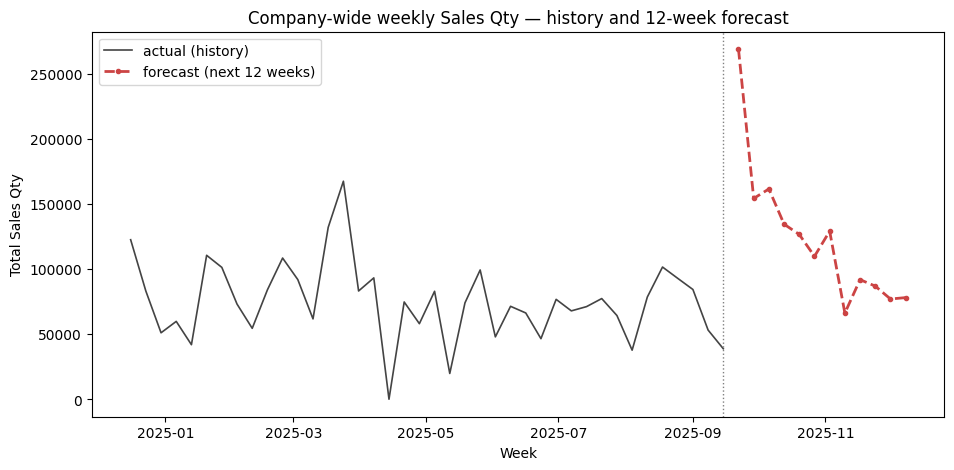

In [7]:
hist = weekly.groupby(WK)[QTY].sum().reset_index().tail(40)
fut = product_fc.groupby("week_start")["forecast_qty"].sum().reset_index()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hist[WK], hist[QTY], color="#444", lw=1.2, label="actual (history)")
ax.plot(fut["week_start"], fut["forecast_qty"], color="#c44", lw=2, ls="--",
        marker="o", ms=3, label="forecast (next 12 weeks)")
ax.axvline(pd.Timestamp(weekly[WK].max()), color="grey", ls=":", lw=1)
ax.set_title("Company-wide weekly Sales Qty — history and 12-week forecast")
ax.set_xlabel("Week"); ax.set_ylabel("Total Sales Qty"); ax.legend()
plt.show()

## Project complete

**Deliverables:** `outputs/forecasts/product_12_week_forecast.csv` and
`product_country_12_week_forecast.csv`.

**Caveats for the report**
* The bias-correction factors are large (≈3–5×), confirming the raw recursive
  LightGBM under-forecasts volume on intermittent demand; the correction trades
  a little point-accuracy for realistic totals.
* The first forecast week is the highest-confidence step; accuracy decays over
  the 12-week horizon (recursive error accumulation).
* Validation used a single 12-week window — a rolling-origin backtest over
  several windows would make the model comparison more robust.